# Tips Prediction Model

### Data Loading

In [59]:
#importing libraries and loading dataset
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
!pip install seaborn
import seaborn as sns
df = pd.read_csv("data_test.csv")
df.head()


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Data Exploration

In [60]:
#exploring dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [61]:
#checking the statistics of our data
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [62]:
#importing from sklearn library
!pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Data Preprocessing

In [63]:
#assigning X and y variables by splitting df
y = df["tip"]
X = df.drop("tip", axis=1)
#performing train_test_Split with random_state=23 for reproducibility and test_size=0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [64]:
#checking shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(195, 6)
(49, 6)
(195,)
(49,)


In [66]:
from sklearn import preprocessing
  

categoricals = ["sex","smoker", "day", "time"]

label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'species'.
X_trainle = X_train[categoricals].apply(label_encoder.fit_transform)

X_train = pd.concat([X_train.drop(categoricals, axis=1), X_trainle], axis=1)
X_train

,total_bill,size,sex,smoker,day,time
243,18.78,2,0,0,3,0
181,23.33,2,1,1,2,0
108,18.24,2,1,0,1,0
69,15.01,2,1,1,1,0
76,17.92,2,1,1,1,0
...,...,...,...,...,...,...
182,45.35,3,1,1,2,0
201,12.74,2,0,1,3,1
40,16.04,3,1,0,1,0
230,24.01,4,1,1,1,0


In [67]:
#transforming test data

X_testle = X_test[categoricals].apply(label_encoder.fit_transform)

# Replace testing columns with transformed versions
X_test = pd.concat([X_test.drop(categoricals, axis=1), X_testle], axis=1)

X_test

,total_bill,size,sex,smoker,day,time
82,10.07,1,0,0,3,1
5,25.29,4,1,0,2,0
92,5.75,2,0,1,0,0
158,13.39,2,0,0,2,0
44,30.40,4,1,0,2,0
128,11.38,2,0,0,3,1
16,10.33,3,0,0,2,0
54,25.56,4,1,0,2,0
47,32.40,4,1,0,2,0
51,10.29,2,0,0,2,0


In [68]:
#fitting oversampled data to our basic model
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()

In [69]:
#checking model performance
from sklearn.metrics import root_mean_squared_error, r2_score
model = linear_model.fit(X_train, y_train)
preds = model.predict(X_test)
rmse = mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 0.86
R² Score: 0.56


Shows that 56% of the variation in tip amounts can be explained by the variables in the model. We can also say that on average, the model's predictions are off by about $0.86.

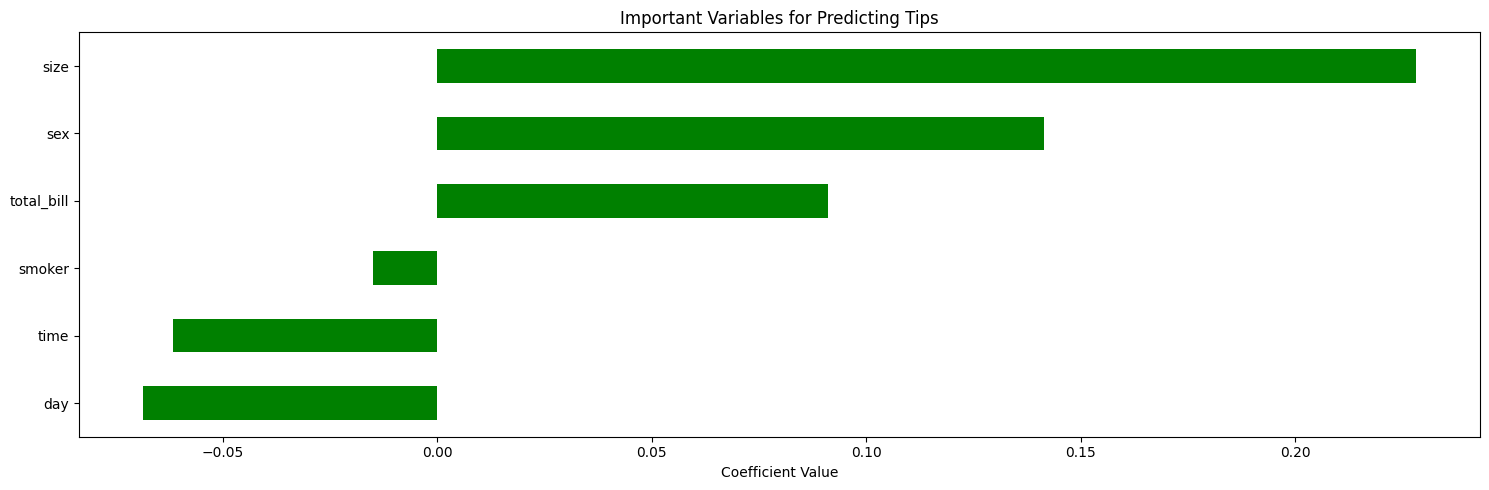

In [70]:
# Bar Chart Visualization
plt.figure(figsize=(15, 5))
critical = pd.Series(model.coef_, index=X.columns).sort_values()
critical.plot(kind='barh', color='green')
plt.title('Important Variables for Predicting Tips')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('variable_importance.png')
plt.show()